____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2501000', 'swot2502000', 'swot2503000', 'swot2504000', 'swot2505000', 'swot2506000', 'swot2507000', 'swot2508000', 'swot2509000', 'swot25010000', 'swot25011000', 'swot25012000', 'swot25013000', 'swot25014000', 'swot2kmnaive', 'swot2km1000', 'swot2km2000', 'swot2km3000', 'swot2km4000', 'swot2km5000', 'swot2km6000', 'swot2km7000', 'swot2km8000', 'swot2km9000', 'swot2km10000', 'swot2km11000', 'swot2km12000', 'swot2km13000', 'swot2km14000', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']),
 dict_keys(['era5']))

_______
# Compute and project (x = cross, y = alg)

In [4]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', spectral_key = '', wd_key = 'era5', ggd_var='fromduacsv', wd_depth='0', wd_model='rio'), 
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', spectral_key = '', wd_key = 'era5', ggd_var='fromduacsv', wd_depth='15', wd_model='rio')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')

DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0])
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[1])

nofilter___swot2kmnaive_fromduacsv__rio_0era5
nofilter___swot2kmnaive_fromduacsv__rio_15era5
Identified SWOT and drifter outliers have been removed


In [5]:
# rotate
def rotate(e, n, phi):
    return np.cos(phi)*e - np.sin(phi)*n, np.sin(phi)*e + np.cos(phi)*n

def crossalg_proj(dsen):
    ds = dsen.copy()
    ds['sumx'] , ds['sumy'] = rotate(dsen.sume, dsen.sumn, dsen.phi)
    dsxy = ds[['sumx','sumy']]
    var = ['acc', 'cor', 'ggd', 'wd', 'sum']
    prod  = [l for l in ds.keys() if 'prodn' in l]
    exc  = [l for l in ds.keys() if 'excn' in l]
    for v in var :
        dsxy[v +'x'] , dsxy[v +'y'] = rotate(dsen[v+'e'], dsen[v+'n'], dsen.phi)

    for direction in ['x', 'y'] : 
            if direction == 'x' : l = {'acc':'accx', 'cor':'corx', 'ggd':'ggdx', 'wd':'wdx'}
            if direction == 'y' : l = {'acc':'accy', 'cor':'cory', 'ggd':'ggdy', 'wd':'wdy'}
                
            # sum 
            dsxy['sum'+direction] = sum([dsxy[l[v]] for v in l])
            
            # simple var + sum- one term
            for v in l :
                dsxy[l[v]] = dsxy[l[v]]
                dsxy['exc'+direction+'_'+v] = dsxy['sum'+direction]-dsxy[l[v]]
                
            #2 by 2 product    
            import itertools  
            couple = list(itertools.combinations(list(l.keys()),2))
            for c in couple : 
                dsxy['prod'+direction+'_'+'_'.join(c)] = dsxy[c[0]+direction] * dsxy[c[1]+direction]
    return dsxy
    
DSr =  crossalg_proj(DS)  

DSSr = DSr.where(DSr.depth==0, drop=True).isel(id_comb=[0])
DSDr = DSr.where(DSr.depth==15, drop=True).isel(id_comb=[1])

# For surface + 15m
DSr = xr.concat([DSSr.isel(id_comb=0), DSDr.isel(id_comb=0)], dim='row_number')

In [6]:
dfr = DSr.to_dataframe().reset_index().set_index('row_number')
dfs = pd.read_csv(ALTI['swot2kmnaive']).set_index('row_number')
dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])

dfrr = pd.concat([dfs[['swh_model', 'abs_cross_track_distance', 'ssh_karin_uncert', 'distance_to_coast']], dfr], axis=1).dropna()


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_19055/590981581.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfs['abs_cross_track_distance'] = abs(dfs['cross_track_distance'])


_________
# Dependency on the cross_track distance

In [42]:
compute_error = 'centrallimit'

dfdtc = dfrr.copy()
dtc_bins = np.linspace(0, 200e3, 50)
dfdtc['dtc_cut'] = pd.cut(dfdtc['distance_to_coast'], dtc_bins, labels=(dtc_bins[1:] + dtc_bins[:-1])/2/1000)
dsdtc = compute_mean_square_groupby(dfdtc, groupby = 'dtc_cut', dirname = ('x', 'y'), compute_error =compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd'] )
dsdtc = dsdtc.where(dsdtc.nb_coloc>0).dropna('dtc_cut')

In [43]:
def exp_decay(dx, dx_constant, amplitude, cst):
    return np.exp(-dx / dx_constant) * amplitude + cst


expfit =  dsdtc.E_ggd.curvefit("dtc_cut", exp_decay)

exp_decay(dsdtc.dtc_cut, *expfit.curvefit_coefficients)

<xarray.DataArray (dtc_cut: 46)> Size: 368B
array([5.39873823, 3.89708119, 2.90136388, 2.24112459, 1.80333375,
       1.51304382, 1.32055865, 1.19292577, 1.10829508, 1.05217824,
       1.01496834, 0.99029523, 0.97393501, 0.9630869 , 0.95589374,
       0.9511241 , 0.94796146, 0.94586438, 0.94447384, 0.94355181,
       0.94294043, 0.94253504, 0.94226623, 0.94208799, 0.9419698 ,
       0.94189143, 0.94183947, 0.94180501, 0.94178217, 0.94176702,
       0.94175697, 0.94175031, 0.94174589, 0.94174296, 0.94174102,
       0.94173973, 0.94173888, 0.94173831, 0.94173794, 0.94173769,
       0.94173753, 0.94173742, 0.94173734, 0.9417373 , 0.94173726,
       0.94173724])
Coordinates:
  * dtc_cut  (dtc_cut) float64 368B 2.041 6.122 10.2 14.29 ... 177.6 181.6 185.7
    param    <U11 44B 'cst'

Text(0.5, 1.0, '')

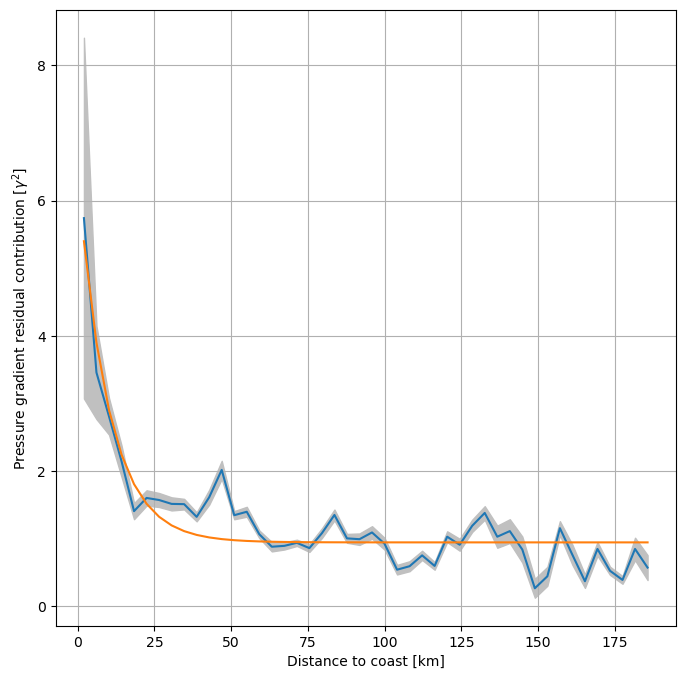

In [44]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsdtc['E_ggd'] = dsdtc.Ex_ggd + dsdtc.Ey_ggd
dsdtc['ser__E_ggd'] = dsdtc.ser__Ex_ggd + dsdtc.ser__Ey_ggd
dsdtc.E_ggd.plot(ax=ax, label='x')

plot_error(dsdtc, 'dtc_cut', 'E_ggd', ax=ax, suf='ser__')

expfit =  dsdtc.E_ggd.curvefit("dtc_cut", exp_decay)
exp_decay(dsdtc.dtc_cut, *expfit.curvefit_coefficients).plot()


ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Distance to coast [km]')
ax.set_title('')